In [19]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [20]:
dataset_path = "leapGestRecog"

print("Dataset Exists:", os.path.exists(dataset_path))

Dataset Exists: True


In [21]:
X = []
y = []

for subject in os.listdir(dataset_path):

    subject_path = os.path.join(dataset_path, subject)

    if os.path.isdir(subject_path):

        for gesture in os.listdir(subject_path):

            gesture_path = os.path.join(subject_path, gesture)

            if os.path.isdir(gesture_path):

                for image in os.listdir(gesture_path)[:100]:

                    img_path = os.path.join(gesture_path, image)

                    img = cv2.imread(
                        img_path,
                        cv2.IMREAD_GRAYSCALE
                    )

                    if img is not None:

                        img = cv2.resize(img, (64, 64))

                        X.append(img.flatten())
                        y.append(gesture)

print("Images Loaded:", len(X))

Images Loaded: 10000


In [22]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(10000, 4096)
(10000,)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
model = SVC(kernel='linear')

model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [26]:
y_pred = model.predict(X_test)

In [27]:
print("Accuracy:",
      accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred
))

Accuracy: 0.9995
               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00       215
         02_l       1.00      1.00      1.00       208
      03_fist       1.00      1.00      1.00       190
04_fist_moved       1.00      1.00      1.00       197
     05_thumb       1.00      1.00      1.00       210
     06_index       1.00      1.00      1.00       190
        07_ok       1.00      1.00      1.00       194
08_palm_moved       1.00      1.00      1.00       223
         09_c       1.00      1.00      1.00       188
      10_down       1.00      1.00      1.00       185

     accuracy                           1.00      2000
    macro avg       1.00      1.00      1.00      2000
 weighted avg       1.00      1.00      1.00      2000



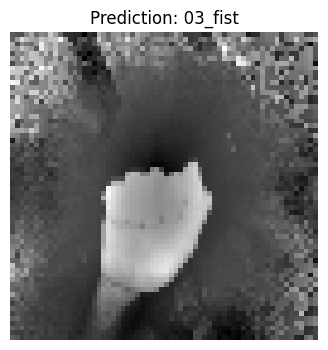

In [28]:
img = X_test[0].reshape(64,64)

plt.figure(figsize=(4,4))
plt.imshow(img, cmap='gray')
plt.title("Prediction: " + str(y_pred[0]))
plt.axis("off")
plt.show()

In [29]:
joblib.dump(model, "hand_gesture_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [30]:
print("""
The Hand Gesture Recognition model was successfully developed using SVM.

The model can classify different hand gestures with good accuracy.

This model can be used in gesture-based human-computer interaction systems.
""")


The Hand Gesture Recognition model was successfully developed using SVM.

The model can classify different hand gestures with good accuracy.

This model can be used in gesture-based human-computer interaction systems.

